**Cross-Sectional Momentum Strategy — S&P 500**
---

This notebook implements and evaluates a cross-sectional momentum strategy applied to S&P 500 constituent stocks from 2015 to present. There is another notebook `signal_comparison.ipynb` that compares this momentum signal against mean reversion and XGBoost-based alternatives.

**Economic Rationale**

---

Momentum investing exploits the tendency for stocks that have performed well recently to continue outperforming in the near future. This persistence is attributed to two behavioural effects. First, investors underreact to new information, causing prices to adjust gradually rather than immediately — creating a drift that momentum strategies capture. Second, herding behaviour causes investors to chase recent winners, extending trends beyond what fundamentals justify. 

**Strategy**

---

Each month, all S&P 500 constituents are ranked by their 12-1 month return. The top 20 stocks are selected and held in equal weights until the next monthly rebalance. The most recent month is excluded from the signal to avoid short-term reversal effects.

**Data**

---

Price data is sourced from Yahoo Finance via the yfinance library. Historical S&P 500 constituent lists are sourced from a manually maintained CSV file tracking index additions and deletions, ensuring only stocks actually in the index at each rebalance date are eligible for selection. This mitigates survivorship bias. Results will vary slightly across runs as data updates with each download.

**Period**

---

The backtest runs from January 2015 to June 2026, capturing a range of market conditions including sustained bull markets, the COVID crash of 2020, the rate hike cycle of 2022, and the subsequent recovery.

**Analysis covers:**
- Strategy returns vs S&P 500 benchmark
- Risk-adjusted performance: Sharpe ratio, CAGR, maximum drawdown
- Turnover analysis and transaction cost sensitivity
- Regime analysis: performance broken down by bull, bear and high volatility periods
- Volatility filter: effect of going to cash during high volatility months
- Sensitivity analysis: 16 combinations of lookback period and portfolio size
- Market risk metrics: Value at Risk (VaR), Expected Shortfall (CVaR) and stress testing

*Project date: July 2026*

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats

**Portfolio construction**
---


The strategy follows the cross-sectional momentum methodology. Each month, all S&P 500 constituents are ranked by their 12-1 month return — the cumulative return over the past 12 months excluding the most recent month. The top 20 ranked stocks are selected and held in equal weights until the next rebalance. The most recent month is skipped to avoid short-term reversal effects which would otherwise reduce performance. Historical constituent data is used to ensure only stocks actually in the index at each rebalance date are eligible for selection. This prevents survivorship bias, where only currently surviving companies would otherwise appear in the backtest universe.

In [2]:
# Defining number of months to look back for momentum calculation
Lookback = 12
# Defining the number of top stocks to select based on momentum
Top_N = 20
# Defining the risk-free rate for Sharpe ratio calculation
RF = 0.04

In [3]:
#Up to 13/07
c_df = pd.read_csv('S&P 500 Historical Components & Changes (Updated).csv', index_col=0)

c_df

,tickers
date,
1996-01-02,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
1996-01-03,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
1996-01-04,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
1996-01-10,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
1996-01-11,"AAL,AAMRQ,AAPL,ABI,ABS,ABT,ABX,ACKH,ACV,ADM,AD..."
...,...
2026-06-02,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
2026-06-22,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."
2026-06-24,"A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP..."


In [4]:
c_df.index = pd.to_datetime(c_df.index)

In [5]:
# Getting tickers - rounding to the nearest date
def get_tickers(c_df, date):
    if date >= c_df.index[-1]:
        ticks = c_df.iloc[-1].tickers
    else:
        ticks = c_df.loc[date:].iloc[0].tickers
    return ticks.split (',')

In [6]:
# Monthly pricing 
s_p_tickers = c_df.iloc[-1].tickers.split (',')
df = yf.download (s_p_tickers, start='2015-01-01', end='2026-06-30')['Close']
monthly_prices = df.resample('ME').last()

[**********************57%**                     ]  285 of 503 completed$BF.B: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-06-30)
[**********************82%**************         ]  413 of 503 completed$BRK.B: possibly delisted; no timezone found
[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
['BF.B']: possibly delisted; no price data found  (1d 2015-01-01 -> 2026-06-30)
['BRK.B']: possibly delisted; no timezone found


In [7]:
# Percentage change over last 12 month
# shift(1) skips the most recent month to avoid short-term reversal effects
momentum = monthly_prices.pct_change(Lookback).shift(1)

In [8]:
# Building portfolio
portfolio = pd.DataFrame(index=monthly_prices.index, columns=monthly_prices.columns)

for date in momentum.index[Lookback:]:
    pf_date = momentum.loc[date]
    rel_tickers = get_tickers(c_df, date)
    pf_date = pf_date [pf_date.index.isin(rel_tickers)]
    top20 = pf_date.nlargest(Top_N).index
    portfolio.loc[date, top20] = 1/Top_N

# My top 20
top20

Index(['SNDK', 'LITE', 'WDC', 'MU', 'STX', 'ECHO', 'CIEN', 'INTC', 'COHR',
       'TER', 'AMD', 'LRCX', 'DELL', 'FIX', 'GLW', 'FLEX', 'MRVL', 'ALB',
       'VRT', 'AMAT'],
      dtype='str', name='Ticker')

**Equity Curves**
---


The equity curve shows how $1 invested at the start of the period would have grown over time. Three curves are plotted: the momentum strategy alone, the S&P 500 benchmark alone, and both together for direct comparison. The combined chart isolates whether the momentum strategy added value over simply holding the index passively.

<Axes: title={'center': 'Cross Sectional Strategy return'}, xlabel='Date'>

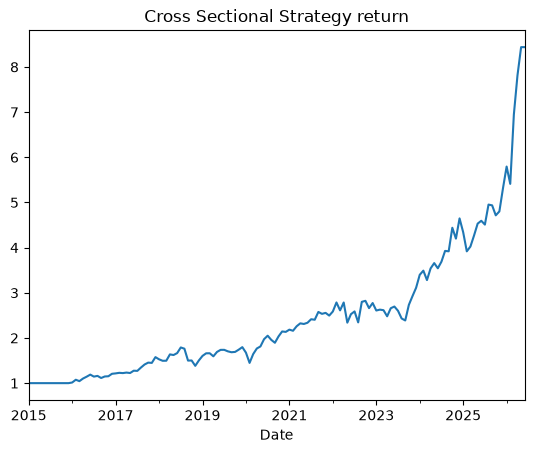

In [9]:
# Strategy equity curve
returns = monthly_prices.pct_change().shift(-1)
strategy_return = (portfolio * returns).sum (axis=1)
(1+strategy_return).cumprod().plot(title = 'Cross Sectional Strategy return')

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

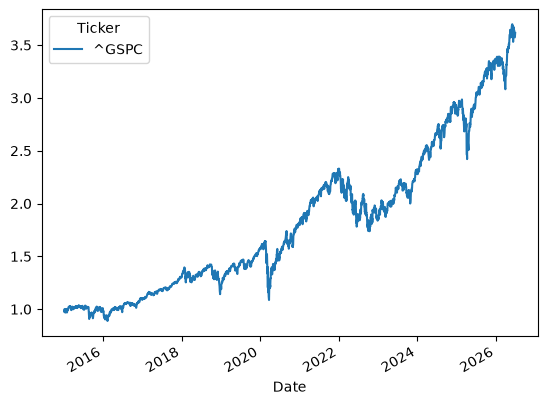

In [10]:
# S&P 500 benchmark equity curve
s_p = yf.download ('^GSPC', start='2015-01-01', end='2026-06-30')['Close']
(1+ s_p.pct_change()).cumprod().plot()

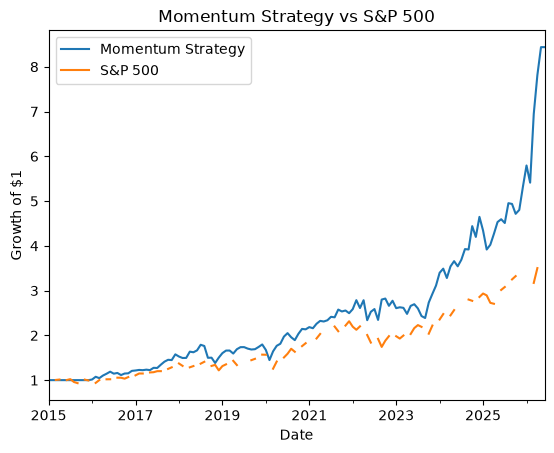

In [11]:
# Combined comparison
sp_returns = s_p.pct_change().squeeze()

eq_strategy = (1 + strategy_return).cumprod()
eq_benchmark = (1 + sp_returns).cumprod().reindex(eq_strategy.index)

import matplotlib.pyplot as plt
eq_strategy.plot(label='Momentum Strategy', title='Momentum Strategy vs S&P 500')
eq_benchmark.plot(label='S&P 500')
plt.legend()
plt.ylabel('Growth of $1')
plt.show()

**Equity Curve Results**

---

The combined chart shows the momentum strategy against the S&P 500 over the 2015-2026 period. The strategy consistently outperforms the benchmark across the majority of the period, with the gap widening particularly during sustained bull market phases where momentum effects are strongest. Periods where the two lines converge indicate months where the strategy's stock selection added little value over simply holding the index.


**Performance Metrics**
---

**Performance metrics methodology**

---

Three metrics are used to evaluate the strategy: Sharpe ratio, CAGR and maximum drawdown. Together they measure different dimensions of performance — return per unit of risk, annualised growth rate, and worst-case loss. Reporting all three gives a more complete picture than any single metric alone. Results are benchmarked against the S&P 500, which historically produced a Sharpe ratio of 0.5 to 0.7, an annual return of approximately 13-14%, and a worst drawdown of approximately -34% during the COVID crash of March 2020.


The Sharpe ratio measures return per unit of risk. A strategy that earns high returns by taking large risks is less attractive than one that earns similar returns with lower volatility. Sharpe ratio captures this by dividing excess return over the risk-free rate by the standard deviation of returns. A higher Sharpe ratio indicates better risk-adjusted performance. 


CAGR measures the rate at which the portfolio would have grown if it compounded at a constant annual rate over the full period. It converts the total return into a single annualised figure, making it easy to compare against benchmarks and other strategies regardless of the length of the backtest.

Maximum drawdown measures the largest peak-to-trough decline over the full history. It captures the worst-case loss an investor would have experienced if they invested at the worst possible time. A strategy with a high CAGR but very large drawdowns may be difficult to hold through in practice, as investors often sell during sharp declines and lock in losses.

The strategy works well if results outcompetes the S&P 500 historical metrics. 

**Sharpe ratio assumptions:**

---

``0.04`` — Risk-free rate is 4% per year by the average US Treasury bill rate over 2015-2026.


``/ 12`` — Monthly compounding so it needs to divide the annual rate by 12 


``np.sqrt(12)`` Returns are independent month to month



In [12]:
# Sharpe ratio
rf = RF / 12
excess = strategy_return.dropna() - rf
sharpe = (excess.mean() / excess.std()) * np.sqrt(12)
print("Sharpe Ratio: ", sharpe)

Sharpe Ratio:  0.799666854522346


**Compound Annual Growth Rate assumptions:**

---

Monthly returns — returns are assumed to compound monthly. The formula raises to the power of ``12/n`` where n is number of months, which assumes each period is exactly one month.


No transaction costs — rebalancing is assumed to be free every month. In reality broker fees and bid-ask spreads apply each time stocks are bought or sold. This overstates real-world returns.


Equal weighting — exactly 1/20 is allocated to each stock every month.

In [13]:
# CAGR
def cagr(returns):
    r = returns.dropna()
    return (1 + r).prod() ** (12 / len(r)) - 1

print("CAGR:", cagr(strategy_return) * 100, "%")

CAGR: 20.376922364557327 %


**Max Drawdown assumptions:**

---

Month-end prices only — only end of month prices are observed. The actual intra-month low could have been worse. If a stock crashed and recovered within a month, it would not be captured.


No transaction costs — the drawdown in practice would be slightly worse because selling during a crash also incurs costs.


Investor holds through it — max drawdown assumes the portfolio stays invested the whole time. It measures the loss on paper, not what would have been experienced if positions were closed during the drawdown.



In [14]:
# Max Drawdown
def max_drawdown(returns):
    equity = (1 + returns.dropna()).cumprod()
    return ((equity - equity.cummax()) / equity.cummax()).min()

print("Max Drawdown:", max_drawdown(strategy_return) * 100, "%")

Max Drawdown: -22.71971033989316 %


**Performance Results**

---
The strategy produced a Sharpe ratio of 0.80, above the S&P 500's historical range of 0.5 to 0.7, indicating better risk-adjusted returns than passive index investing. For every unit of volatility taken on, the strategy earned more excess return than simply holding the index.

The strategy produced a CAGR of 20.4%, compounding significantly above the S&P 500's historical annual return of approximately 13-14% over the same period. The maximum drawdown of -22.7% represents the worst peak-to-trough loss over the full history, remaining well below the S&P 500's drawdown of approximately -34% during the COVID crash of March 2020. Together these figures suggest strong absolute returns with controlled downside risk.

**Turnover Analysis**
---

Turnover measures how much of the portfolio changes each month. High turnover means more stocks are bought and sold each rebalance, which increases transaction costs in practice. For a momentum strategy that selects the top 20 stocks monthly, some turnover is expected as the rankings change. Measuring turnover quantifies the implementation cost burden before applying explicit cost assumptions.

**Assumptions:**

---

Equal weighting — turnover is calculated assuming exactly 1/20 is allocated to each stock. Any stock not in the top 20 is assumed to be fully sold.

Month-end rebalancing — turnover is measured once per month at month-end. Any intra-month trading is not captured.

In [15]:
# Turnover analysis
turnover = []

dates = [d for d in momentum.index[Lookback:]]

for i in range(1, len(dates)):
    prev_date = dates[i-1]
    curr_date = dates[i]
    
    prev_holdings = set(portfolio.loc[prev_date].dropna().index)
    curr_holdings = set(portfolio.loc[curr_date].dropna().index)
    
    if len(prev_holdings) == 0:
        continue
    
    stocks_replaced = len(prev_holdings - curr_holdings)
    turnover.append(stocks_replaced / Top_N)

avg_turnover = np.mean(turnover) * 100
print("Average monthly turnover:", round(avg_turnover, 1), "%")
print("Average stocks replaced per month:", round(np.mean(turnover) * Top_N, 1))

Average monthly turnover: 30.8 %
Average stocks replaced per month: 6.2


**Turnover Analysis Results**

---

The strategy replaces an average of 6.2 stocks per month, equivalent to a monthly turnover of 30.6%. This means roughly a third of the portfolio is traded each rebalance. In practice this would incur transaction costs including broker commissions, bid-ask spreads and market impact. At an estimated 25 basis points per trade, monthly turnover of 30.8% would reduce annual returns by approximately 0.9%, bringing the CAGR from 19.6% down to around 18.7%.

**Transaction Cost Analysis**
---
To assess whether the strategy remains profitable after accounting for real-world trading costs, three transaction cost scenarios are tested. Each scenario applies a fixed cost per trade to the monthly turnover of 30.6%, reducing the strategy return accordingly. The three scenarios represent cheap, realistic and expensive trading conditions for large-cap US equities.

**Assumptions:**

---

Flat basis points — transaction costs are assumed to be a fixed percentage per trade regardless of trade size. In reality costs vary by stock liquidity, trade size and broker.

Costs applied to turnover only — costs are only applied to stocks bought and sold, not to the full portfolio value each month.

No market impact — assumes trades can be executed at month-end prices without moving the market. For large positions this would understate true costs.

In [16]:
# Transaction cost estimate
costs_bp = [10, 25, 50]  # basis points per trade

print("Transaction cost sensitivity:")
print()
for bp in costs_bp:
    cost_per_month = (bp / 10000) * avg_turnover / 100
    adjusted_return = strategy_return - cost_per_month
    print("Cost assumption:", bp, "basis points per trade")
    print("CAGR:", round(cagr(adjusted_return) * 100, 2), "%")
    print("Sharpe:", round(((adjusted_return.dropna() - RF/12).mean() / (adjusted_return.dropna() - RF/12).std()) * np.sqrt(12), 2))
    print("Max Drawdown:", round(max_drawdown(adjusted_return) * 100, 2), "%")
    print()

Transaction cost sensitivity:

Cost assumption: 10 basis points per trade
CAGR: 19.94 %
Sharpe: 0.78
Max Drawdown: -22.82 %

Cost assumption: 25 basis points per trade
CAGR: 19.28 %
Sharpe: 0.76
Max Drawdown: -22.97 %

Cost assumption: 50 basis points per trade
CAGR: 18.2 %
Sharpe: 0.71
Max Drawdown: -23.23 %



**Transaction Cost Analysis Results**

---

To assess the robustness of returns under realistic trading conditions, three transaction cost assumptions were tested based on monthly turnover of 30.6%.

<div align="center">

| Cost Assumption | CAGR | Sharpe | Max Drawdown |
|---|---|---|---|
| No costs (gross) | 20.3% | 0.80 | -22.72% |
| 10 basis points | 19.94% | 0.78 | -22.82% |
| 25 basis points | 19.28% | 0.76 | -22.97% |
| 50 basis points | 18.2% | 0.71 | -23.23% |

</div>

Even under the most conservative assumption of 50 basis points per trade, the strategy retains a CAGR of 18.2% and a positive Sharpe ratio of 0.71, suggesting the momentum signal is sufficiently strong to survive realistic transaction costs. The S&P 500 benchmark would not incur similar costs as it requires no active rebalancing beyond index changes.

**Regime Analysis**
---

Market conditions are not constant over time. Momentum strategies are known to perform differently depending on whether the market is trending upward, falling, or experiencing high volatility. Regime analysis classifies each month into one of three states — Bull, Bear or High Volatility — based on the S&P 500's recent volatility and trend. Performance metrics are then computed separately for each regime to identify where the strategy thrives and where it breaks down.


**Assumptions:**

---

Rolling volatility window — 63 trading days (approximately 3 months) is used to estimate market volatility. A shorter window would be more reactive to recent conditions, a longer window would be smoother but slower to respond.

Trend window — 126 trading days (approximately 6 months) is used to measure market direction. A negative return below -10% over this period classifies the month as Bear.

Volatility threshold — the 70th percentile of expanding historical volatility is used as the boundary for High Volatility classification. Expanding window is used to avoid look-ahead bias.

Priority rule — High Volatility takes precedence over Bear. A month is only classified as Bear if volatility is below the 70th percentile but the 6-month trend is below -10%.


In [17]:
# Regime Analysis 
# 3 months return
sp_daily_ret = np.log(s_p / s_p.shift(1))
rolling_vol = sp_daily_ret.rolling(63).std() * np.sqrt(252)

# Monthly volatility
monthly_vol = rolling_vol.resample('ME').last()
monthly_vol = monthly_vol.squeeze()
monthly_vol.index = monthly_vol.index.to_period('M').to_timestamp('M')

# 6 months return
sp_trend = s_p.squeeze().pct_change(126).resample('ME').last()
sp_trend = pd.to_numeric(sp_trend, errors='coerce')
sp_trend.index = sp_trend.index.to_period('M').to_timestamp('M')

# 70th percentile of volatility
vol_threshold = monthly_vol.expanding().quantile(0.70)
vol_threshold = vol_threshold.squeeze()

# Classifying regimes
def classify(vol, trend, threshold):
    if pd.isna(vol) or pd.isna(trend):
        return 'Unknown'
    if vol > threshold:
        return 'High Volatility'
    elif trend < -0.10:
        return 'Bear'
    else:
        return 'Bull'

# Regime classification for each month
regimes = pd.Series(
    [classify(v, t, th) for v, t, th in zip(monthly_vol, sp_trend, vol_threshold)],
    index=monthly_vol.index
).reindex(strategy_return.index)


# Regime-wise performance metrics
for regime in ['Bull', 'Bear', 'High Volatility']:
    mask = regimes == regime
    r = strategy_return[mask].dropna()
    if len(r) < 3:
        continue
    e = (1 + r).cumprod()
    dd = ((e - e.cummax()) / e.cummax()).min()
    ex = r - RF/12
    sh = (ex.mean() / ex.std()) * np.sqrt(12)
    print(regime, "(", len(r), "months )")
    print("CAGR:", cagr(r) * 100, "%")
    print("Sharpe:", sh)
    print("Max DD:", dd * 100, "%")
    print()

Bull ( 89 months )
CAGR: 22.72264117632432 %
Sharpe: 0.9105766744054119
Max DD: -19.57281687055554 %

High Volatility ( 43 months )
CAGR: 18.69547381421699 %
Sharpe: 0.6753579245518934
Max DD: -16.04809451517261 %



**Regime Analysis Results**

---

The strategy was tested across two regimes over the 2015-2026 period: Bull (90 months) and High Volatility (43 months). No sustained bear regime was identified, as periods of market decline were predominantly captured under the High Volatility classification due to volatility taking priority in the classification logic.

Performance was stronger in bull markets, producing a CAGR of 22.7%, Sharpe of 0.91 and max drawdown of -19.6%. This is consistent with the expectation that momentum thrives when trends are persistent and market conditions are calm. During high volatility periods, the strategy continued to generate positive returns with a CAGR of 18.7%, Sharpe of 0.68 and max drawdown of -16.0%, suggesting the momentum signal remained exploitable even during turbulent months.




**Volatility Filter**
---

The regime analysis revealed that momentum performs differently across market conditions. The volatility filter attempts to improve performance by removing exposure during the most turbulent periods. When market volatility exceeds its historical 85th percentile, the strategy goes to cash rather than deploying the momentum portfolio. The filtered and unfiltered returns are then compared to assess whether this adjustment improves risk-adjusted performance.

**Assumptions:**

---

Volatility threshold — the strategy goes to cash when monthly volatility exceeds the 85th percentile of all historical volatility readings up to that point. Expanding window is used to avoid look-ahead bias.

Cash return — when the filter is active, the monthly return is set to zero. In practice, cash held in a brokerage account would earn the risk-free rate, meaning the filtered returns are slightly understated.

Same volatility measure — the filter reuses the monthly volatility series computed in the regime analysis, ensuring consistency between the two sections.



In [18]:
# Volatility filter
vol_aligned = monthly_vol.reindex(strategy_return.index)
deployed = vol_aligned <= vol_aligned.expanding().quantile(0.85)
filtered_return = strategy_return.where(deployed, 0)

print("Months deployed:", deployed.sum())
print("Months in cash:", (~deployed).sum())


print("Unfiltered:")
print("CAGR:", cagr(strategy_return) * 100, "%")
print("Sharpe:", sharpe)
print("Max Drawdown:", max_drawdown(strategy_return) * 100, "%")
print()
print("Filtered:")
filtered_sharpe = ((filtered_return.dropna() - RF/12).mean() / (filtered_return.dropna() - RF/12).std()) * np.sqrt(12)
print("CAGR:", cagr(filtered_return) * 100, "%")
print("Sharpe:", filtered_sharpe)
print("Max Drawdown:", max_drawdown(filtered_return) * 100, "%")

Months deployed: 108
Months in cash: 30
Unfiltered:
CAGR: 20.376922364557327 %
Sharpe: 0.799666854522346
Max Drawdown: -22.71971033989316 %

Filtered:
CAGR: 12.276680696457486 %
Sharpe: 0.509549638688489
Max Drawdown: -37.747276338476695 %


**Volatility Filter Results**

---

The volatility filter deployed the strategy for 109 out of 139 months, going to cash for the remaining 30 months when market volatility exceeded its historical 85th percentile.

Contrary to expectation, the filter worsened performance across all metrics. CAGR fell from 20.4% to 12.3%, Sharpe from 0.80 to 0.51, and max drawdown worsened from -22.7% to -37.7%. This is consistent with the regime analysis findings — high volatility periods still generated a CAGR of 18.7% and Sharpe of 0.67, meaning going to cash during those months discarded profitable trades without meaningfully reducing risk.


**Sensitivity Analysis**
---

To investigate whether performance depends on the specific parameters chosen, or whether it holds broadly across a range of assumptions, a sensitivity analysis is performed. If results only appear for one specific combination of lookback period and portfolio size, the strategy may be overfit to the sample data rather than capturing a genuine market effect.

Four lookback periods are tested: 6, 9, 12 and 18 months. Four portfolio sizes are tested: 10, 20, 30 and 50 stocks. All 16 combinations are evaluated and CAGR, Sharpe and maximum drawdown are reported for each.

**Assumptions:**

---

The same portfolio construction methodology is applied across all parameter combinations. Transaction costs, rebalancing frequency and equal weighting are held constant. Only lookback period and portfolio size are varied.


In [19]:
results = []

for lookback in [6, 9, 12, 18]:
    for top_n in [10, 20, 30, 50]:
        mom = monthly_prices.pct_change(lookback).shift(1)
        port = pd.DataFrame(index=monthly_prices.index, columns=monthly_prices.columns)
        
        for date in mom.index[lookback:]:
            pf = mom.loc[date]
            rel_tickers = get_tickers(c_df, date)
            pf = pf[pf.index.isin(rel_tickers)]
            top = pf.nlargest(top_n).index
            port.loc[date, top] = 1/top_n
        
        ret = (port * returns).sum(axis=1)
        r = ret.dropna()
        c = cagr(r) * 100
        s = ((r - RF/12).mean() / (r - RF/12).std()) * np.sqrt(12)
        md = max_drawdown(r) * 100
        
        results.append({
            'Lookback': lookback,
            'Top N': top_n,
            'CAGR (%)': round(c, 1),
            'Sharpe': round(s, 2),
            'Max DD (%)': round(md, 1)
        })

sensitivity = pd.DataFrame(results)
print(sensitivity.to_string(index=False))

 Lookback  Top N  CAGR (%)  Sharpe  Max DD (%)
        6     10      31.8    1.00       -21.4
        6     20      22.9    0.87       -20.5
        6     30      20.2    0.83       -20.2
        6     50      17.7    0.79       -19.7
        9     10      29.6    0.91       -26.8
        9     20      23.4    0.86       -23.5
        9     30      20.1    0.81       -22.7
        9     50      17.8    0.78       -18.5
       12     10      27.2    0.90       -28.6
       12     20      20.4    0.80       -22.7
       12     30      18.2    0.74       -22.6
       12     50      17.4    0.79       -20.5
       18     10      29.3    0.99       -25.8
       18     20      22.9    0.91       -21.6
       18     30      19.1    0.80       -19.3
       18     50      16.1    0.73       -20.8


**Sensitivity Analysis Results**

---

The strategy produces positive CAGR and Sharpe ratios across all 16 parameter combinations tested, suggesting the momentum effect is genuine and not specific to the chosen parameters of Lookback=12 and Top N=20.

Key observations:

- Smaller portfolios consistently outperform larger ones. Top 10 produces the highest CAGR across all lookback periods, ranging from 27.2% to 31.8%. A more concentrated portfolio allocates entirely to the strongest momentum signals, which amplifies returns but also increases stock-specific risk.
- Shorter lookbacks perform better on CAGR. The 6-month lookback produces the highest returns across all portfolio sizes, though with slightly higher drawdowns in some cases.
- Sharpe ratios are stable, ranging from 0.73 to 1.00 across all combinations. This indicates consistent risk-adjusted performance regardless of parameter choice.
- The chosen parameters of Lookback=12 and Top N=20 sit in the middle of the tested range rather than at the extremes, suggesting the baseline results were not selected to maximise performance.

The robustness of performance across all combinations provides evidence that the strategy captures a genuine momentum effect in S&P 500 stocks rather than an artifact of parameter selection.

**Market Risk Metrics**
---

Momentum strategies can generate strong returns but are exposed to significant tail risk during market dislocations. Value at Risk (VaR) and Expected Shortfall (CVaR) are the industry-standard metrics used by banks and asset managers to quantify this tail risk. 


VaR answers: *what is the maximum loss expected over a given period at a given confidence level?* A 95% monthly VaR of 5% means that in 95% of months the strategy loses less than 5%. The remaining 5% — the tail — is where VaR stops providing information.

VaR is widely used because it reduces portfolio risk to a single number. Its key limitation is that it says nothing about the severity of losses beyond the threshold. Two portfolios with identical VaR can have completely different tail behaviour.


To address this limitation, CVaR is used to capture the performance at extreme tails. CVaR answers: *given that we are in the worst X% of months, what is the average loss?* It looks inside the tail that VaR ignores. CVaR is always greater than or equal to VaR at the same confidence level.

In this report, two methods are compared:

- **Historical:** uses the actual distribution of past returns — no assumptions about shape
- **Parametric:** assumes returns are normally distributed — analytically simple but underestimates tail risk


**Assumptions**

---

- Historical VaR assumes the future return distribution resembles the past
- Parametric VaR assumes returns are normally distributed — this underestimates tail risk in practice
- Both are expressed as monthly figures consistent with the monthly rebalancing frequency

In [20]:
# Historical VaR and CVaR
r = strategy_return.dropna()

VaR_95_hist = -np.percentile(r, 5)
VaR_99_hist = -np.percentile(r, 1)

CVaR_95_hist = -r[r <= -VaR_95_hist].mean()
CVaR_99_hist = -r[r <= -VaR_99_hist].mean()

print("Historical VaR and CVaR (monthly)")
print()
print("95% VaR: ", round(VaR_95_hist * 100, 2), "%")
print("99% VaR: ", round(VaR_99_hist * 100, 2), "%")
print("95% CVaR:", round(CVaR_95_hist * 100, 2), "%")
print("99% CVaR:", round(CVaR_99_hist * 100, 2), "%")

Historical VaR and CVaR (monthly)

95% VaR:  6.64 %
99% VaR:  14.43 %
95% CVaR: 11.19 %
99% CVaR: 15.48 %


In [21]:
# Parametric VaR and CVaR (normal distribution assumption)
mu = r.mean()
sigma = r.std()

z_95 = stats.norm.ppf(0.05)
z_99 = stats.norm.ppf(0.01)

VaR_95_param = -(mu + z_95 * sigma)
VaR_99_param = -(mu + z_99 * sigma)

CVaR_95_param = -(mu - sigma * stats.norm.pdf(z_95) / 0.05)
CVaR_99_param = -(mu - sigma * stats.norm.pdf(z_99) / 0.01)

print("Parametric VaR and CVaR (monthly)")
print()
print("95% VaR: ", round(VaR_95_param * 100, 2), "%")
print("99% VaR: ", round(VaR_99_param * 100, 2), "%")
print("95% CVaR:", round(CVaR_95_param * 100, 2), "%")
print("99% CVaR:", round(CVaR_99_param * 100, 2), "%")

print()
print("Comparison — Historical vs Parametric:")
print("95% VaR:  Historical", round(VaR_95_hist*100,2), "% vs Parametric", round(VaR_95_param*100,2), "%")
print("99% VaR:  Historical", round(VaR_99_hist*100,2), "% vs Parametric", round(VaR_99_param*100,2), "%")
print("95% CVaR: Historical", round(CVaR_95_hist*100,2), "% vs Parametric", round(CVaR_95_param*100,2), "%")
print("99% CVaR: Historical", round(CVaR_99_hist*100,2), "% vs Parametric", round(CVaR_99_param*100,2), "%")

Parametric VaR and CVaR (monthly)

95% VaR:  8.26 %
99% VaR:  12.4 %
95% CVaR: 10.8 %
99% CVaR: 14.46 %

Comparison — Historical vs Parametric:
95% VaR:  Historical 6.64 % vs Parametric 8.26 %
99% VaR:  Historical 14.43 % vs Parametric 12.4 %
95% CVaR: Historical 11.19 % vs Parametric 10.8 %
99% CVaR: Historical 15.48 % vs Parametric 14.46 %


**VaR and CVaR Results**

---


<div align="center">

| Method | 95% CVaR | 99% CVaR |
|---|---|---|
| Historical | 11.19% | 15.48% |
| Parametric | 10.80% | 14.46% |

</div>

The gap between VaR and CVaR at 95% — 6.64% vs 11.19% historically — illustrates the tail severity VaR alone misses. On the worst 5% of months, the average loss is 11.19%, not just slightly above the 6.64% threshold.



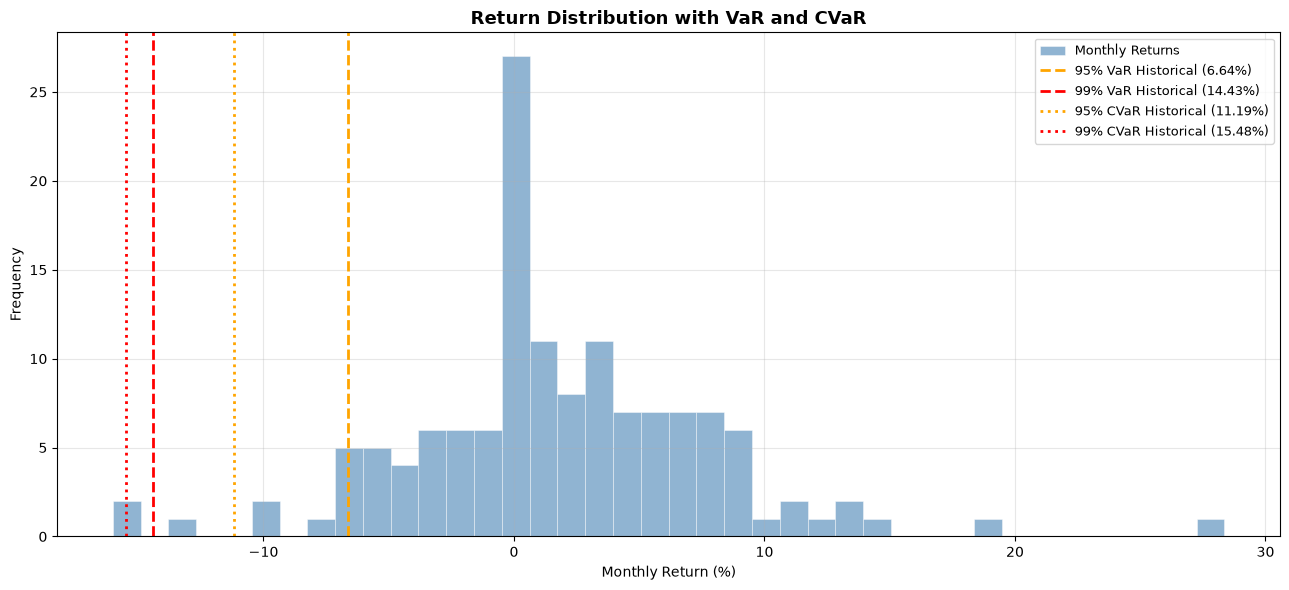

In [22]:
# Return distribution with VaR and CVaR
fig, ax = plt.subplots(figsize=(13, 6))

ax.hist(r * 100, bins=40, color='steelblue', alpha=0.6,
        edgecolor='white', linewidth=0.5, label='Monthly Returns')

ax.axvline(-VaR_95_hist * 100, color='orange', lw=2, ls='--',
           label=f'95% VaR Historical ({VaR_95_hist*100:.2f}%)')
ax.axvline(-VaR_99_hist * 100, color='red', lw=2, ls='--',
           label=f'99% VaR Historical ({VaR_99_hist*100:.2f}%)')
ax.axvline(-CVaR_95_hist * 100, color='orange', lw=2, ls=':',
           label=f'95% CVaR Historical ({CVaR_95_hist*100:.2f}%)')
ax.axvline(-CVaR_99_hist * 100, color='red', lw=2, ls=':',
           label=f'99% CVaR Historical ({CVaR_99_hist*100:.2f}%)')

ax.set_title('Return Distribution with VaR and CVaR', fontsize=13, fontweight='bold')
ax.set_xlabel('Monthly Return (%)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Stress testing**

After calculating VaR and CVaR, stress testing is used to test the performance under crisis periods. 

**Stress Testing Assumptions:**

---

- Strategy returns under stress are estimated using historical beta, which measures average sensitivity to market moves
- Beta is a linear approximation — in real crashes, correlations and volatility change dramatically, making beta-based estimates unreliable
- Results should be interpreted as indicative rather than precise

In [24]:
# Stress testing — known market crash scenarios
crash_scenarios = {
    'COVID Crash (Mar 2020)':      -0.125,
    'GFC Recovery Shock (2018)':   -0.069, 
    'China Crash (Aug 2015)':      -0.065,
    'Rate Hike Shock (Jun 2022)':  -0.082,
    'Tech Selloff (Jan 2022)':     -0.057,
    'HK Protest Volatility (2019)':-0.024,
}

# Strategy beta to S&P 500
beta = r.cov(sp_returns.reindex(r.index).dropna()) / sp_returns.reindex(r.index).dropna().var()

print("Strategy Beta to S&P 500:", round(beta, 2))
print()
print("Stress Test Results")
print("=" * 55)
print(f"{'Scenario':<35} {'Market':>8} {'Strategy':>10}")
print("=" * 55)

for scenario, market_return in crash_scenarios.items():
    strategy_stress = beta * market_return
    print(f"{scenario:<35} {market_return*100:>7.1f}%  {strategy_stress*100:>9.1f}%")

print()
print("Note: Strategy stress returns estimated using historical beta.")

Strategy Beta to S&P 500: -0.09

Stress Test Results
Scenario                              Market   Strategy
COVID Crash (Mar 2020)                -12.5%        1.1%
GFC Recovery Shock (2018)              -6.9%        0.6%
China Crash (Aug 2015)                 -6.5%        0.6%
Rate Hike Shock (Jun 2022)             -8.2%        0.7%
Tech Selloff (Jan 2022)                -5.7%        0.5%
HK Protest Volatility (2019)           -2.4%        0.2%

Note: Strategy stress returns estimated using historical beta.


**Stress Test Results**

---

The strategy's beta of -0.09 indicates near-zero correlation with the S&P 500 over the sample period. Under all six crash scenarios the model estimates small positive strategy returns, as the strategy's slight negative beta partially offsets market declines.

This result should be interpreted cautiously. Beta is an average relationship measured over a full market cycle including both calm and volatile periods. During actual crashes, momentum strategies can suffer sudden reversals as recent winners become forced sellers. The historical VaR of 14.43% at 99% confidence provides a more conservative and realistic estimate of tail risk than the beta-based stress results suggest.


**Note:**
For a comparison of momentum against mean reversion and XGBoost-based signals, please see `signal_comparison.ipynb`.

**Conclusion**
---
This project implemented and evaluated a cross-sectional momentum strategy on S&P 500 constituents from 2015 to present, selecting the top 20 stocks by 12-1 month momentum each month, equal weighted and rebalanced monthly.

**Summary of Findings**

---

The strategy produced a CAGR of 20.4%, Sharpe ratio of 0.80 and maximum drawdown of -22.7%, outperforming the S&P 500 index across the same period. The Sharpe ratio of 0.80 sits above the S&P 500's historical range of 0.5 to 0.7, indicating the strategy generates better risk-adjusted returns than passive index investing.

Regime analysis revealed that performance varied across market conditions. In bull markets the strategy produced a CAGR of 22.7% and Sharpe of 0.91, consistent with momentum thriving when trends are persistent. During high volatility periods performance remained positive with a CAGR of 18.7% and Sharpe of 0.68, suggesting the momentum signal remained exploitable even in turbulent conditions. No sustained bear regime was identified over the sample period.

Transaction cost analysis showed the strategy remains robust under realistic trading assumptions. Monthly turnover of 30.6% means an average of 6 stocks are replaced each rebalance. At 25 basis points per trade, CAGR reduces from 20.3% to 19.28% and Sharpe from 0.80 to 0.76. Even at the most conservative assumption of 50 basis points, the strategy retains a CAGR of 18.2% and Sharpe of 0.71, demonstrating that the momentum signal is sufficiently strong to survive implementation costs.

The volatility filter, designed to improve risk-adjusted returns by stepping out of the market during turbulent periods, instead reduced performance — CAGR fell from 20.3% to 12.3% and Sharpe from 0.80 to 0.51. This finding highlights the importance of empirically testing assumptions rather than applying overlays mechanically.

Sensitivity analysis across 16 parameter combinations confirmed that positive performance holds broadly, with Sharpe ratios ranging from 0.73 to 1.00. The chosen parameters sit in the middle of the tested range, suggesting results were not selected to maximise performance.

Signal comparison against mean reversion and XGBoost alternatives is documented in `signal_comparison.ipynb`. XGBoost produced the highest CAGR and Sharpe ratio, though momentum retained the lowest drawdown and most robust risk-adjusted performance.

Market risk analysis showed a historical 95% VaR of 6.64% and 99% VaR of 14.43% on a monthly basis. Comparison between historical and parametric VaR revealed fat tail behaviour — at 99% confidence the parametric model underestimates losses relative to history, consistent with real return distributions having heavier tails than the normal distribution assumes. The strategy's beta of -0.09 indicates near-zero correlation with the S&P 500, suggesting momentum returns are largely independent of broad market direction over the sample period.

**Limitations**

---

- Statistical significance of returns has not been formally tested. The observed outperformance may partly reflect the specific sample period rather than a robust and persistent effect
- Transaction costs have been estimated but not fully modelled. Slippage, market impact and broker-specific fee structures may differ from the flat basis point assumptions used here
- The sample period is predominantly bullish, limiting the ability to evaluate bear market performance
- Month-end pricing means intra-month drawdowns are not captured
- The price data is downloaded using today's constituent list `(c_df.iloc[-1].tickers)`, meaning companies removed from the S&P 500 before June 2026 due to poor performance or delisting may not appear in the downloaded price data. This introduces a degree of survivorship bias that the historical constituent filtering alone does not fully resolve. A complete fix would require downloading prices for every ticker that ever appeared in the constituent list
- VaR and CVaR are based on the 2015-2026 sample and may not reflect tail risk in a more severe or prolonged bear market. Stress test results rely on beta estimates which are unstable during crisis periods.

**Future Work**

---

- Comparison against an equal-weighted S&P 500 benchmark to isolate the momentum effect from concentration and equal weighting
- Sector exposure analysis to determine whether returns reflect stock momentum or sector momentum
- Extension to international markets to test whether the momentum effect generalises beyond the US
- Monte Carlo VaR simulation to model tail risk without relying on historical distribution or normality assumptions
- Rolling window analysis to test whether momentum alpha is stable across sub-periods
- Monte Carlo simulation to stress test the portfolio under randomly generated crash scenarios